In [1]:
import sys
sys.path.append("..")
from typing import List, TypedDict
import operator
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

# Import message types from LangChain core messages.
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# Import StateGraph and special END node.
from langgraph.graph import StateGraph, END

# Define our state schema: all messages (chat history) will be collected here.
class TravelState(TypedDict):
    messages: List[BaseMessage]

In [2]:
from agente_investimento import TratatandoDadosFundamentalistasComparacao

trat = TratatandoDadosFundamentalistasComparacao(tics=["PETR4"], data_inicio="2024-01-01")

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
await trat.coletando_dados_tickers()

[[Document(metadata={'receita_liquida': 117720.0, 'resultado_bruto': 60700.0, 'ebit': 44030.0, 'amortizacao': -16650.0, 'ebitda': 60680.0, 'lucro_liquido': 23700.0, 'lucro_por_acao': '1.82', 'tic': 'PETR4', 'capex_tres_meses': -14050.0, 'fluxo_caixa_investimentos': -16440.0, 'aumento_reducao_caixa_equivalentes': -3920.0, 'preço_lucro': '4.93', 'preço_receita_líquida': '1.11', 'preço_fco': '2.60', 'preço_ativo_total': '0.51', 'preço_ebit': '3.14', 'ev_ebit': '4.69', 'market_cap_empresa': 561670.0, 'enterprise_value': 812930.0, 'dividend_yield': 0.1328, 'retorno_sobre_ativo_inicial': 0.113, 'margem_bruta': 0.525, 'margem_liquida': 0.224, 'margem_ebit': 0.353, 'alavancagem_financeira': '2.62', 'passivo_patrimonio_liquido': '1.62'}, page_content='2024-03-31'),
  Document(metadata={'receita_liquida': 122260.0, 'resultado_bruto': 61050.0, 'ebit': 33540.0, 'amortizacao': -16360.0, 'ebitda': 49900.0, 'lucro_liquido': -2610.0, 'lucro_por_acao': '-  0.20', 'tic': 'PETR4', 'capex_tres_meses': -15

In [4]:
import sys
sys.path.append("..")
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode 
from typing import Optional
import pandas as pd
from langchain_core.documents import Document
from agente_investimento import TratandoDadosValuationComparacao
from agente_investimento import DadosIndicadoresTecnicos
from agente_investimento import TratarDadosNoticiasComparacao
from agente_investimento import TratatandoDadosFundamentalistasComparacao
import os

@tool
async def dados_fundamentalistas(tic: str, 
                                 data_inicio: Optional[str] = "2024-01-01", 
                                 data_fim: Optional[str] = None,
                                 ) -> List[List[Document]]:
        """ 
       Retrieve fundamental data for a specific ticker.

        Gets fundamental data for the specified period or defaults to last 4 periods
        if no start date is provided.

        Args:
            tic (str): Stock ticker symbol (ex: 'PETR4').
            data_inicio (str, optional): Start date in the format 'YYYY-MM-DD'. Defaults to '2024-01-01'.
            data_fim (str, optional): End date in the format 'YYYY-MM-DD'. Defaults to None.

        Returns:
            LIST of Documents: List containing fundamental data
        """

        df = TratatandoDadosFundamentalistasComparacao(tics=[tic], data_inicio=data_inicio, data_fim=data_fim)
        df_dados = await df.coletando_dados_tickers()
        return df_dados

@tool
async def dados_tecnicos(ticker: str, periodo: str = "5Y", intervalo: str = "1mo") -> pd.DataFrame:
    """
    Retrieves technical indicators data for a given asset.

    This asynchronous function collects technical data such as price, volume and indicators
    for technical analysis of a specific stock.

    Args:
        ticker (str): Stock symbol on B3 (e.g. 'PETR4')
        periodo (str, optional): Historical data period. Defaults to "5Y" (5 years).
            Accepted options:
            - "1d": 1 day
            - "5d": 5 days
            - "1mo": 1 month 
            - "3mo": 3 months
            - "6mo": 6 months
            - "1y": 1 year
            - "2y": 2 years
            - "5y": 5 years
            - "10y": 10 years
            - "ytd": Year to date
            - "max": Maximum history
        intervalo (str, optional): Interval between data points. Defaults to "1wk" (weekly).
            Accepted options:
            - "1m": 1 minute
            - "2m": 2 minutes 
            - "5m": 5 minutes
            - "15m": 15 minutes
            - "30m": 30 minutes
            - "60m": 60 minutes
            - "90m": 90 minutes
            - "1h": 1 hour
            - "1d": 1 day
            - "5d": 5 days
            - "1wk": 1 week
            - "1mo": 1 month
            - "3mo": 3 months

    Returns:
        pd.DataFrame: DataFrame containing the collected technical indicators

    Example:
        ```python
        data = await dados_tecnicos("PETR4", periodo="1Y", intervalo="1d")
        ```
    """
    ind_tecnicos = DadosIndicadoresTecnicos(ticker=ticker,periodo=periodo, intervalo=intervalo)
    df_dados = ind_tecnicos.pegando_indicadores_tecnicos()
    return df_dados


@tool
async def dados_valuation(tick: str) -> dict:
    
    """
    Retrieves valuation data for a given stock ticker.

    This asynchronous function calculates various valuation metrics including Gordon Growth Model valuation,
    Discounted Cash Flow valuation, and current market metrics.

    Args:
        tick (str): Stock ticker symbol (e.g., 'PETR4')

    Returns:
        dict: A dictionary containing four key elements:
            - Gordon Growth Model valuation table and calculated price
            - Projected cash flows table and DCF valuation 
            - Financial metrics used in calculations
            - Current market price

    Example:
        ```python
        valuation_data = await dados_valuation('PETR4')
        ```

    Output Format:
        The returned dictionary contains:
        1. Gordon Growth Model analysis with dividend data, growth rates, and price target
        2. Discounted cash flow projections for next 5 years with present values
        3. Key financial metrics like EBIT margin, revenue, WACC, debt levels etc.
        4. Current market price for comparison

    Note:
        The valuation calculations use various assumptions and should be used as one of multiple
        inputs in investment decisions, not as the sole decision factor.
    """

    trat = TratandoDadosValuationComparacao(tickers=[tick])

    valuation_preco = await trat.dados_valuation()

    return valuation_preco



serper_api_key = os.getenv("SERPER_API_KEY")
api_secret_groq = os.getenv("GROQ_API_KEY")

@tool
async def dados_sentimento(ticker: str) -> str:
    """
    Retrieves and processes market sentiment data based on news for a specific stock.

    This asynchronous function uses external APIs (Serper and Groq) to collect and analyze
    recent news related to the specified ticker, generating a market sentiment analysis.

    Args:
        ticker (str): Stock ticker symbol (e.g., 'PETR4') for sentiment analysis

    Returns:
        str: Formatted string containing the sentiment analysis based on collected news,
            including headlines, summaries and overall market sentiment assessment

    Example:
        ```python
        sentiment_data = await dados_sentimento('PETR4')
        ```

    Notes:
        - Requires valid API keys for Serper and Groq configured as environment variables
        - The return may include multiple news items and their respective sentiment analyses
        - Function is asynchronous and must be called with await
    """
    trat_noticias = TratarDadosNoticiasComparacao(tickers=[ticker], 
                                              api_secret_serper=serper_api_key,
                                              api_secret_groq=api_secret_groq,
                                              options=None,)
    return await trat_noticias.tickes_news()
    

## chat bot fundamentalista

In [5]:
## chat bot fundamentalista
querry = "Qual da acoes tem o melhor fundamento fundamentos da PETR4, BBDC4, ITUB4?"

tools_fundamentalista = [dados_fundamentalistas]

tool_node_fundamentalista = ToolNode(tools_fundamentalista)

prompt_fundamentalista = """
Você é um assistente especializado em investimentos do mercado brasileiro. 
Sua tarefa é analisar os dados fundamentalistas de uma ação específica responder a pergunta {messages} do usuario.
Para isso, você deve utilizar a ferramenta de dados fundamentalistas fornecida a voce.
Use os dados retornados pela ferramenta para basear sua análise.
Seja objetivo e claro em suas respostas, fornecendo informações relevantes sobre a empresa,
seus indicadores financeiros e perspectivas de investimento.
A sua resposta deve ter no máximo 100 palavras.

Limitações:
1. Você não deve fornecer recomendações de compra ou venda de ações.
2. Se não houver informações suficientes sobre a empresa, informe que não é possível realizar a análise.

Question: {messages}
"""

prompt_fundamentalista = ChatPromptTemplate.from_template(prompt_fundamentalista)

llm_fundamentalista = ChatGroq(
    model="deepseek-r1-distill-llama-70b",
    temperature=0,
    stop_sequences=None
)

llm_chain_fundamentalista = prompt_fundamentalista | llm_fundamentalista.bind_tools(tools_fundamentalista)

# Agora passe o input como um dicionário com a chave "messages"
response = llm_chain_fundamentalista.invoke({
    "messages": "Qual dessas 3 acoes PETR4, BBDC4, ITUB4 tem o melhor fundamento??",
    
}).tool_calls


In [6]:
response

[{'name': 'dados_fundamentalistas',
  'args': {'data_fim': None, 'data_inicio': '2024-01-01', 'tic': 'PETR4'},
  'id': 'call_x1w7',
  'type': 'tool_call'}]

In [7]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver


class TravelStateFundamentalista(TypedDict):
    messages: List[BaseMessage]


def should_continue_fundamentalista(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    #print(last_message.tool_calls)
    if last_message.tool_calls:
        return "tools_fundamentalista"
    return END


# Define the function that calls the model
async def call_model_fundamentalista(state: MessagesState):
    messages = state["messages"]
    #response = await llm_with_tools.ainvoke(messages)
    response = await llm_chain_fundamentalista.ainvoke({"messages": messages,})
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


workflow_fundamentalista = StateGraph(MessagesState)

workflow_fundamentalista.add_node("agente_fundamentalista", call_model_fundamentalista)
workflow_fundamentalista.add_node("tools_fundamentalista", tool_node_fundamentalista)

workflow_fundamentalista.add_edge(START, "agente_fundamentalista")
workflow_fundamentalista.add_conditional_edges("agente_fundamentalista", should_continue_fundamentalista, ["tools_fundamentalista", END])
workflow_fundamentalista.add_edge("tools_fundamentalista", "agente_fundamentalista")

graph_fundametalista = workflow_fundamentalista.compile()

In [8]:
response = await graph_fundametalista.ainvoke({"messages": "Entre PETR4 e VALE3  qual tem o melhor fundamento"})

In [16]:
response['messages'][3].content.split("\n\n")

['']

In [17]:
response['messages']

[HumanMessage(content='Entre PETR4 e VALE3  qual tem o melhor fundamento', additional_kwargs={}, response_metadata={}, id='eabd084e-a398-4622-ad40-c5a46f164c61'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_21a6', 'function': {'arguments': '{"data_fim":null,"data_inicio":"2024-01-01","tic":"PETR4"}', 'name': 'dados_fundamentalistas'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 211, 'prompt_tokens': 557, 'total_tokens': 768, 'completion_time': 0.767272727, 'prompt_time': 0.035807202, 'queue_time': 0.168088845, 'total_time': 0.803079929}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_87ec4d1ec3', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-e70fb8d1-b9b7-4f0a-ac84-1c6dd117be17-0', tool_calls=[{'name': 'dados_fundamentalistas', 'args': {'data_fim': None, 'data_inicio': '2024-01-01', 'tic': 'PETR4'}, 'id': 'call_21a6', 'type': 'tool_call'}], usage_metadata={'input_tokens': 557, 'output_tok

## Chat bot analise tecnica

In [20]:
## chat bot fundamentalista
querry = "Quero análise tecnica da PETR4"

tools_tecnicos = [dados_tecnicos]

tool_node_tecnicos = ToolNode(tools_tecnicos)

prompt_tecnicos = """
Você é um assistente especializado em investimentos do mercado brasileiro. 
Sua tarefa é analisar os dados tecnicos de uma ação específica responder a pergunta {messages} do usuario.
Para isso, você deve utilizar a ferramenta de dados fundamentalistas fornecida a voce.
Use os dados retornados pela ferramenta para basear sua análise.
Seja objetivo e claro em suas respostas, fornecendo informações relevantes sobre a empresa,
seus indicadores financeiros e perspectivas de investimento.
A sua resposta deve ter no máximo 200 palavras.

Limitações:
1. Você não deve fornecer recomendações de compra ou venda de ações.
2. Se não houver informações suficientes sobre a empresa, informe que não é possível realizar a análise.

Question: {messages}
"""

prompt_tecnicos = ChatPromptTemplate.from_template(prompt_tecnicos)

llm_tecnicos = ChatGroq(
    model="meta-llama/llama-4-maverick-17b-128e-instruct",
    temperature=0,
    stop_sequences=None
)

llm_chain_tecnicos = prompt_tecnicos | llm_tecnicos.bind_tools(tools_tecnicos)

# Agora passe o input como um dicionário com a chave "messages"
response_tecnicos = llm_chain_tecnicos.invoke({
    "messages": "Como esta analise tecnica da petr4 E VALE3?",
    
}).tool_calls


In [21]:
response_tecnicos

[{'name': 'dados_tecnicos',
  'args': {'intervalo': '1d', 'periodo': '1Y', 'ticker': 'PETR4'},
  'id': 'call_j6k4',
  'type': 'tool_call'},
 {'name': 'dados_tecnicos',
  'args': {'intervalo': '1d', 'periodo': '1Y', 'ticker': 'VALE3'},
  'id': 'call_3m1v',
  'type': 'tool_call'}]

In [22]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver


class TravelStateTecnicos(TypedDict):
    messages: List[BaseMessage]


def should_continue_tecnicos(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools_tecnicos"
    return END


# Define the function that calls the model
async def call_model_tecnicos(state: MessagesState):
    messages = state["messages"]
    response = await llm_chain_tecnicos.ainvoke({"messages": messages,})
    return {"messages": [response]}


workflow_tecnicos = StateGraph(MessagesState)

workflow_tecnicos.add_node("agente_tecnicos", call_model_tecnicos)
workflow_tecnicos.add_node("tools_tecnicos", tool_node_tecnicos)

workflow_tecnicos.add_edge(START, "agente_tecnicos")
workflow_tecnicos.add_conditional_edges("agente_tecnicos", should_continue_tecnicos, ["tools_tecnicos", END])
workflow_tecnicos.add_edge("tools_tecnicos", "agente_tecnicos")

graph_tecnicos = workflow_tecnicos.compile()

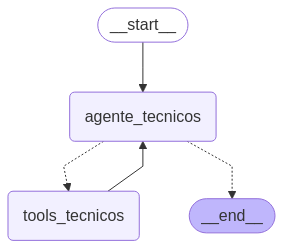

In [23]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import Image, display

try:
    display(Image(graph_tecnicos.get_graph().draw_mermaid_png()))
except Exception:
    print("Exception")
    pass

In [ ]:
await graph_tecnicos.ainvoke({"messages": "Como esta analise tecnica da petr4?"})

## Chat principal

In [ ]:

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate


#llm_with_tools = ChatGroq(model="meta-llama/llama-4-maverick-17b-128e-instruct").bind_tools(tools)

llm = ChatGroq(
    model="qwen-qwq-32b"
    #model="meta-llama/llama-4-maverick-17b-128e-instruct"
    )

empresas_df = pd.read_csv(
        "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv",
        encoding="utf-8",
    )

empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])

template = """
        You are an investment analysis agent with over 10 years of experience. You receive the following data.
    
        Rules for ticker identification:
        - Brazilian tickers usually end with numbers 
        - If the user mentions only the company name (ex: "Petrobras"), identify the correct ticker from the list above
        - If there is ambiguity, prefer the most liquid ticker (usually ending in 3 or 4)
        Available Companies and Tickers:
        {empresas_tickers}

        Guidelines:
        - Be concise and direct
        - Use professional but accessible language
        - Acknowledge limitations when uncertain
        - Always mention investment risks
        - Avoid direct buy/sell recommendations

        Provide confidence level of analysis
        Indicate if, based on agent inputs, the recommendation is to buy, sell or hold the stock.

        ## Investment Analysis
        - Commentary on the asset

        ## Confidence Level
---

*Note:*  
If there is insufficient data about the company, respond normally based on a generic conversation.
IMPORTANT: ALWAYS PROVIDE THE RESPONSE IN PORTUGUESE (BRAZILIAN PORTUGUESE).

Question: {messages}
"""

prompt = ChatPromptTemplate.from_template(template)

llm_chain = prompt | llm



In [ ]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition

from typing import Literal

# Opção 1: Baseado em tool calls específicos
def should_continue(state: MessagesState) -> Literal["agente_fundamentalista", "agente_tecnicos", END]:
    """
    Roteia baseado nos tool calls da última mensagem
    """
    messages = state["messages"]
    last_message = messages[-1]
    
    # Se não há tool calls, finaliza
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return END
    
    # Verifica qual ferramenta foi chamada
    for tool_call in last_message.tool_calls:
        tool_name = tool_call.get('name', '')
        
        # Roteamento baseado no nome da ferramenta
        if 'fundamental' in tool_name.lower() or 'dados_fundamentalistas' in tool_name:
            return "agente_fundamentalista"
        elif 'tecnico' in tool_name.lower() or 'analise_tecnica' in tool_name:
            return "agente_tecnicos"
    
    # Se nenhuma ferramenta específica, finaliza
    return END



# Define the function that calls the model
async def call_model(state: MessagesState):
    messages = state["messages"]
    #response = await llm_with_tools.ainvoke(messages)
    response = await llm_chain.ainvoke({"messages": messages,
                                    "empresas_tickers": empresas_tickers})
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


workflow = StateGraph(MessagesState)

workflow.add_node("agente_principal", call_model)
workflow.add_node("agente_fundamentalista", graph_fundametalista)
workflow.add_node("agente_tecnicos", graph_tecnicos)

workflow.add_edge(START, "agente_principal")
workflow.add_conditional_edges(
    "agente_principal",
    should_continue,
    {
        "agente_fundamentalista": "agente_fundamentalista",
        "agente_tecnicos": "agente_tecnicos",
        END: END,
    }
)
workflow.add_edge("agente_fundamentalista", "agente_principal")
workflow.add_edge("agente_tecnicos", "agente_principal")


#workflow.add_edge("agente_principal", END)

memory = MemorySaver()
#app = workflow.compile(checkpointer=memory)
app = workflow.compile()

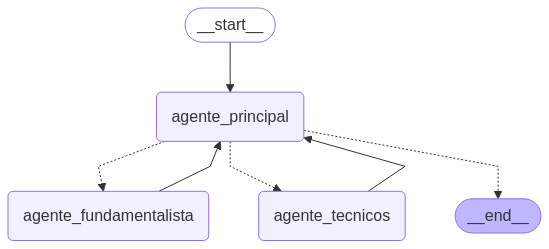

In [ ]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Exception")
    pass

In [ ]:
response = await app.ainvoke({"messages": "Como esta os fundamentos e analise tecnica da petr4?"})

InternalServerError: Error code: 503 - {'error': {'message': 'Service Unavailable', 'type': 'internal_server_error'}}

In [ ]:
response

{'messages': [HumanMessage(content='Como esta os fundamentos e analise tecnica da petr4?', additional_kwargs={}, response_metadata={}, id='d8b73650-1b93-4b18-989d-1534c4c8f701'),
  AIMessage(content='## Análise de Investimento da PETR4\n\nA PETR4 é uma das ações mais negociadas no mercado brasileiro e representa a participação preferencial da Petrobras. A Petrobras é uma empresa estatal brasileira de energia que atua nos setores de exploração, produção, refino e distribuição de petróleo e gás natural.\n\n### Fundamentos\n\nOs fundamentos da Petrobras são influenciados por vários fatores, incluindo:\n\n- **Preços do Petróleo**: A variação nos preços internacionais do petróleo tem um impacto significativo na receita da empresa.\n- **Produção e Reservas**: A capacidade de produção e as reservas de petróleo e gás são fundamentais para a sustentabilidade a longo prazo.\n- **Investimentos e Desempenho Operacional**: A eficiência nos investimentos e no desempenho operacional afeta diretamente